## 실행 환경 확인

이 셀은 Jupyter Notebook과 Python 실행 환경이 정상적으로 동작하는지 확인하기 위한 예시 코드임.

- Python이 정상적으로 실행되는지 점검
- 노트북 셀 실행이 되는지 확인
- 이후 분석 코드가 문제없이 돌기 위한 기본 체크

In [1]:
print("hello world")

hello world


## 데이터 샘플 확인

이 코드는 실제 GA4 이벤트 데이터의 형태를 살펴보는 단계임.

- 테이블에서 일부 행을 불러와 데이터가 제대로 들어왔는지 확인



In [2]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT *
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_20210131`
LIMIT 10
"""

df = client.query(query).to_dataframe()
print(df.head())
print(df.columns.tolist())

  event_date   event_timestamp       event_name  \
0   20210131  1612069510766593        page_view   
1   20210131  1612069529243877           scroll   
2   20210131  1612069515781635        page_view   
3   20210131  1612069530073506  user_engagement   
4   20210131  1612069510766593    session_start   

                                        event_params  \
0  [{'key': 'gclid', 'value': {'string_value': No...   
1  [{'key': 'debug_mode', 'value': {'string_value...   
2  [{'key': 'debug_mode', 'value': {'string_value...   
3  [{'key': 'page_location', 'value': {'string_va...   
4  [{'key': 'ga_session_number', 'value': {'strin...   

   event_previous_timestamp  event_value_in_usd  event_bundle_sequence_id  \
0                      <NA>                 NaN                6595101026   
1                      <NA>                 NaN                9011338476   
2                      <NA>                 NaN               -6830522854   
3                      <NA>                 NaN 

##  이벤트별 집계 확인

이 코드는 어떤 이벤트가 얼마나 많이 발생했는지 확인하는 단계임.

- `event_name` 기준으로 이벤트 수 집계
- 각 이벤트의 총 발생 건수 확인
- 사용자 수(`unique_users`)도 함께 보며 이벤트의 실제 참여 규모를 파악

주요 확인 포인트:
- 어떤 이벤트가 발생하는지
- 사용자 기반으로도 규모가 큰 이벤트가 있는지
- acquisition 분석에서 핵심 이벤트를 선별할 수 있는지

주의 사항:
- first_visit의 이벤트 발생건수가 해당 이벤트를 발생시킨 고유 유저의 수보다 148건이 높게 측정됨 따라서 일부 유저에 대한 중복이 있을 수 있음을 생각해야함

In [3]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    event_name,
    COUNT(*) AS event_count,
    COUNT(DISTINCT user_pseudo_id) AS unique_users
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20210131'
GROUP BY event_name
ORDER BY event_count DESC
"""

df = client.query(query).to_dataframe()
print(df)

             event_name  event_count  unique_users
0             page_view      1350428        269792
1       user_engagement      1058721        213004
2                scroll       493072        138098
3             view_item       386068         61252
4         session_start       354970        267116
5           first_visit       257462        257314
6        view_promotion       190104        102443
7           add_to_cart        58543         12545
8        begin_checkout        38757          9715
9           select_item        31007         13180
10  view_search_results        26172         14449
11    add_shipping_info        19722          9714
12     add_payment_info        13899          5751
13     select_promotion         9450          8164
14             purchase         5692          4419
15                click         1446          1010
16       view_item_list           71            44


##  이벤트 파라미터별 확인

이 코드는 각 이벤트에서 어떤 매개변수들이 얼마나 많이 발생하는지 확인하는 단계임.

- `param.key` 기준으로 어떤 파라미터가 자주 나오는지 집계
- 각 이벤트별로 어떤 정보가 수집되고 있는지 확인

주요 확인 포인트:
- 사용자 유입 경로, 캠페인, 소스 등에 쓰이는 파라미터 키를 찾는지
- acquisition 관련 파라미터가 어떤 이름으로 저장되는지

In [4]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    event_name,
    param.key AS param_key,
    COUNT(*) AS occurrence_count
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`,
UNNEST(event_params) AS param
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20210131'
GROUP BY event_name, param_key
ORDER BY event_name, occurrence_count DESC
"""

df = client.query(query).to_dataframe()
print(df)

              event_name      param_key  occurrence_count
0       add_payment_info       currency             13899
1       add_payment_info  page_location             13899
2       add_payment_info     page_title             13899
3       add_payment_info     debug_mode             13899
4       add_payment_info  ga_session_id             13899
..                   ...            ...               ...
275  view_search_results       all_data             17771
276  view_search_results         source               361
277  view_search_results         medium               361
278  view_search_results       campaign               361
279  view_search_results           term                31

[280 rows x 3 columns]


##  first_visit 관련 핵심 파라미터 추출

이 코드는 `first_visit` 이벤트에서 실제로 어떤 파라미터가 중요한지 확인하는 마지막 단계임.

- `first_visit` 이벤트만 필터링
- `occurrence_count` 기준으로 내림차순 정렬
- acquisition 분석에서 가장 자주 확인해야 할 파라미터를 추출

주요 확인 포인트:
- `first_visit` 이벤트에서 어떤 파라미터가 자주 발생하는지
- 유입 경로, 캠페인, 채널 관련 키를 찾는지
- 이후 실제 acquisition 분석의 기준 변수를 정립하는지

In [5]:
first_visit_params = df[df['event_name'] == 'first_visit'].sort_values('occurrence_count', ascending=False)
print(first_visit_params)

     event_name              param_key  occurrence_count
84  first_visit          page_location            257462
85  first_visit      ga_session_number            257462
86  first_visit          ga_session_id            257462
87  first_visit  engaged_session_event            257368
88  first_visit        session_engaged            257178
89  first_visit             page_title            254591
90  first_visit          page_referrer            165332


## 추가 분석 포인트: 상위 컬럼으로 분류되는 유입 변수

신규 유입을 세분화해서 분석할 때, 지역, 채널과 같은 변수는 이벤트 파라미터 안에 있는 값으로 확인되는 것이 아니라, 별도의 상위 컬럼으로 저장돼 있음.

예를 들어:
- 지역 정보는 `geo` 컬럼으로 존재함.
- 채널 정보는 `traffic_source` 컬럼으로 존재함.

즉, `event_params`에서 파라미터를 확인하는 것만으로는 신규 유입의 세부 분류를 이해하기 어렵고, 상위 컬럼을 살펴봐야 함.

In [6]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    DATE_TRUNC(PARSE_DATE('%Y%m%d', event_date), WEEK(MONDAY)) AS week_start,
    COUNT(DISTINCT user_pseudo_id) AS new_users
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
    AND event_name = 'first_visit'
GROUP BY week_start
ORDER BY week_start
"""

df = client.query(query).to_dataframe()
print(df)

    week_start  new_users
0   2020-11-02      16500
1   2020-11-09      14594
2   2020-11-16      16906
3   2020-11-23      18737
4   2020-11-30      21200
5   2020-12-07      27563
6   2020-12-14      24226
7   2020-12-21      17015
8   2020-12-28      16304
9   2021-01-04      22464
10  2021-01-11      21010
11  2021-01-18      20231
12  2021-01-25      18669


## 주별 신규 사용자 집계

`event_name = 'first_visit'`인 이벤트를 기준으로, 각 사용자의 첫 방문을 한 번만 계산하여 주별 신규 사용자 수를 집계함.

- 2020년 11월 1일은 일요일이라 주별 집계 기준인 월요일 시작주에 포함되지 않으므로 분석 범위에서 제외함

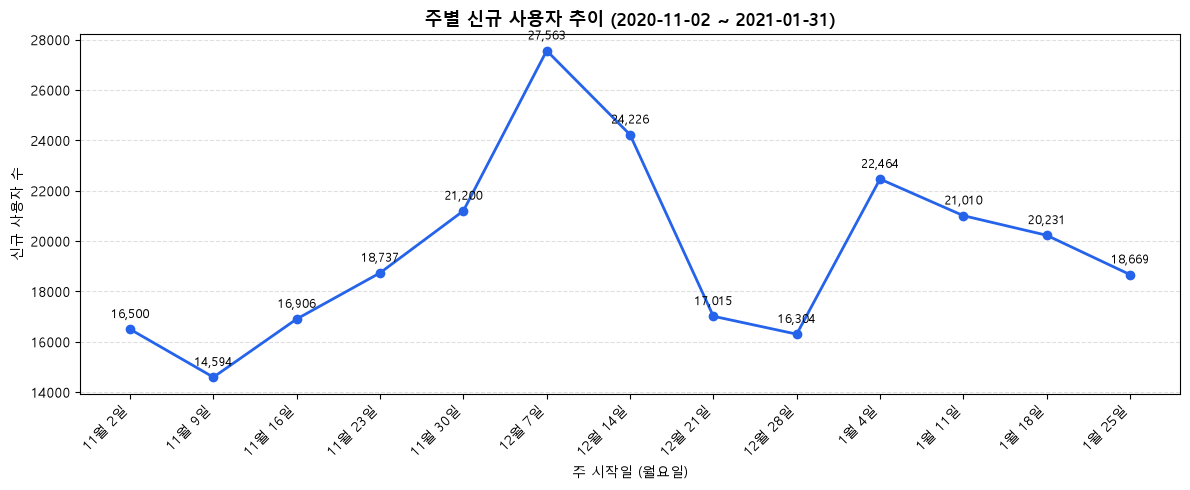

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 설정 (Windows 기준, Mac은 'AppleGothic'으로 변경)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 요일 한글 매핑 (Monday=0 ~ Sunday=6)
weekday_kr = ['월', '화', '수', '목', '금', '토', '일']

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['week_start'], df['new_users'], marker='o', linewidth=2, color='#2563eb')

# 각 포인트 위에 값 라벨 표시
for x, y in zip(df['week_start'], df['new_users']):
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

ax.set_title('주별 신규 사용자 추이 (2020-11-02 ~ 2021-01-31)', fontsize=13, fontweight='bold')
ax.set_xlabel('주 시작일 (월요일)')
ax.set_ylabel('신규 사용자 수')

# x축 눈금을 13개 week_start 값 전부로 명시 지정
ax.set_xticks(df['week_start'])

# 라벨을 "11월 2일" 형식으로 커스텀 포맷
xtick_labels = [f"{d.month}월 {d.day}일" for d in df['week_start']]
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('weekly_new_users.png', dpi=150)
plt.show()

### 구간별 가설과 이후 분석 단계

#### 1) 12/7 주 피크는 특정 채널이 견인했을 것이다

11/23 주(18,737)보다 2주 뒤인 12/7 주가 더 높게 나타난 점은, 단순한 블랙프라이데이 효과라기보다 일정 시차가 있는 다른 원인이 있을 가능성이 있음


#### 2) 12/21~12/28 주 급락은 채널별로 다르게 나타날 것이다

연말 하락이 모든 채널에서 동일하게 나타난다면 계절적 소비 패턴으로 볼 수 있지만, 특정 채널만 급락했다면 광고 예산 소진 또는 집행 중단의 영향일 가능성이 큼.


#### 3) 1/4 주 반등은 신규 캠페인 재개 또는 새해 검색 트래픽 때문일 것이다

12/28 주(16,304) 대비 1/4 주(22,464) 급등은 새해 소비 트렌드 변화 또는 광고 재개 효과를 반영했을 가능성이 있음.


#### 4) 이 변동이 특정 지역에 편중되어 있을 것이다

블랙프라이데이, 크리스마스, 새해는 특정 국가에서 더 강하게 나타날 수 있으므로, 지역별 비중을 확인하면 유입 변동의 원인을 더 정확히 추정할 수 있음.


### 이후 분석 단계

가장 우선적으로 검증해야 할 축은 채널임. 채널이 왜 이런 변동이 발생했는지에 더 직접적으로 설명할 가능성이 높기 때문임.

다음 단계는 주별 × 채널 교차 집계로 넘어가, 각 구간에서 어떤 채널이 변동을 주도했는지 확인하는 것임.

이를 통해 상승/하락 구간의 원인을 보다 명확하게 해석할 수 있음.

---

## 캠페인별 신규 사용자 집계

이 코드는 `first_visit` 이벤트를 기준으로 캠페인별 신규 사용자 유입 규모를 집계함.

- `traffic_source.name`별 신규 유입 건수 확인
- 어떤 캠페인 또는 캠페인 분류가 유입 변동을 주도했는지 파악


In [8]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    traffic_source.name AS campaign_name,
    COUNT(*) AS event_cnt
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE event_name = 'first_visit'
    AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
GROUP BY campaign_name
ORDER BY event_cnt DESC
"""

df = client.query(query).to_dataframe()
print(df)

    campaign_name  event_cnt
0       (organic)      98074
1        (direct)      60899
2         <Other>      60141
3      (referral)      36367
4  (data deleted)         35


## 매체별 신규 사용자 집계

이 코드는 `first_visit` 이벤트를 기준으로 유입 매체별 신규 사용자 수를 집계함.

- `traffic_source.medium`별 유입 건수 비교
- Organic, Paid, Referral, Direct 등 채널별 규모 파악
- 주별 신규 사용자 변동을 설명하는 주요 매체 확인


In [9]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    traffic_source.medium AS medium,
    COUNT(*) AS event_cnt
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE event_name = 'first_visit'
    AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
GROUP BY medium
ORDER BY event_cnt DESC
"""

df = client.query(query).to_dataframe()
print(df)

           medium  event_cnt
0         organic      98074
1          (none)      60899
2         <Other>      46127
3        referral      36367
4             cpc      14013
5  (data deleted)         36


## 소스별 신규 사용자 집계

이 코드는 `first_visit` 이벤트를 기준으로 유입 소스별 신규 사용자 수를 집계함.

- `traffic_source.source`별 유입 건수 비교
- 검색엔진, 외부 사이트 등 구체적인 유입 출처 확인
- 동일한 매체 안에서 어떤 소스가 유입을 주도했는지 파악


In [10]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    traffic_source.source AS source,
    COUNT(*) AS event_cnt
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE event_name = 'first_visit'
    AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
GROUP BY source
ORDER BY event_cnt DESC
"""

df = client.query(query).to_dataframe()
print(df)

                            source  event_cnt
0                           google     103676
1                          <Other>      78250
2                         (direct)      60899
3  shop.googlemerchandisestore.com      12656
4                   (data deleted)         35


## 캠페인, 매체, 소스 조합별 신규 사용자 집계

이 코드는 캠페인명, 매체, 소스를 함께 묶어 유입 조합별 신규 사용자 수를 집계함.

- 세 가지 유입 차원을 동시에 비교
- 각 조합의 실제 유입 규모 확인
- 이후 채널 그룹핑과 캠페인 단위 분석 가능 여부 판단에 활용


In [18]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    traffic_source.name AS campaign_name,
    traffic_source.medium AS medium,
    traffic_source.source AS source,
    COUNT(*) AS event_cnt
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE event_name = 'first_visit'
    AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
GROUP BY campaign_name, medium, source
ORDER BY campaign_name ASC, medium ASC
"""

df = client.query(query).to_dataframe()
print(df)

     campaign_name          medium                           source  event_cnt
0   (data deleted)  (data deleted)                          <Other>          1
1   (data deleted)  (data deleted)                   (data deleted)         34
2         (direct)          (none)                         (direct)      60899
3        (organic)         organic                           google      89662
4        (organic)         organic                          <Other>       8412
5       (referral)        referral  shop.googlemerchandisestore.com      12656
6       (referral)        referral                          <Other>      23711
7          <Other>  (data deleted)                   (data deleted)          1
8          <Other>         <Other>                           google          1
9          <Other>         <Other>                          <Other>      46126
10         <Other>             cpc                           google      14013



### 각 조합 설명

| # | 조합 | 쉬운 설명 |
|---|---|---|
| 0 | (data deleted) / (data deleted) / (data deleted) | 세 필드 모두 프라이버시 설정으로 정보 삭제 |
| 1 | (data deleted) / (data deleted) / \<Other\> | campaign·medium은 삭제, source만 미분류로 남은 극소수 예외 |
| 2 | (direct) / (none) / (direct) | 주소창 직접 입력, 북마크, 카톡·문자 링크 — 추적 신호(리퍼럴 정보) 자체가 없음 |
| 3 | (organic) / organic / \<Other\> | 구글이 아닌 다른 검색엔진(네이버, 빙 등)으로 자연 유입 |
| 4 | (organic) / organic / google | 구글 검색 결과(광고 아님)를 클릭해서 들어옴 — 가장 흔한 유입 |
| 5 | (referral) / referral / \<Other\> | 외부 사이트(블로그·커뮤니티 등) 링크 클릭, 출처는 불명 |
| 6 | (referral) / referral / shop.googlemerchandisestore.com | 사이트 내부 이동인데 리퍼럴로 잘못 잡힌 경우. source가 외부 도메인이 아닌 자기 자신이라 "제3자 소개"라는 referral의 정의를 충족하지 못함 → 제3자 개입 없이 온 Direct의 정의에 더 부합 |
| 7 | \<Other\> / (data deleted) / (data deleted) | name은 미분류, medium·source는 삭제된 극소수 예외 |
| 8 | \<Other\> / \<Other\> / google | 구글에서 온 건 확실하나 방식(medium)은 미분류인 극소수 예외 |
| 9 | \<Other\> / \<Other\> / \<Other\> | 어디서 왔는지 신호는 있으나 GA4가 못 알아본 미분류 유입 (앱 인앱브라우저 등) |
| 10 | \<Other\> / cpc / google | 구글 유료 검색 광고 클릭 (캠페인명이 안 붙어서 \<Other\>) |

### 그룹핑 과정

세부 source는 다르지만 **유입 "방식"(medium) 이 같으면 하나의 채널로 묶는 게 분석에 유리**함.

- **Organic Search**: #3 + #4 → medium=organic 기준으로 통합 (구글이든 아니든 "자연 검색"이라는 본질은 동일)
- **Direct**: #2 + #6 → #6(자사 도메인 셀프 리퍼럴)은 source가 외부가 아닌 자기 자신이라 "제3자 소개" 조건을 충족하지 못하므로, 정의상 Referral이 아닌 Direct로 재분류
- **Paid Search**: #10 단독 (campaign_name이 \<Other\>여도 medium=cpc면 명확히 유료광고)
- **Referral**: #5 단독 (실제 외부 도메인 미상이지만 제3자 개입은 확인됨)
- **Unassigned**: #0, #1, #7, #8, #9 → 전부 합쳐서 "채널 특정 불가"로 처리 (총 46,163건)

**결론: 그룹핑은 `medium` 기준을 기본으로 하되, `source`가 자사 도메인인 경우(#6)만 예외적으로 `source`까지 함께 확인해 Direct로 재분류함.**

### 데이터 상 한계 — 캠페인 단위 분석 불가

- `campaign_name`에 실제 마케팅 캠페인명(예: "2020_black_friday_sale")이 단 한 건도 없고, 전부 GA4 자동 placeholder(`(organic)`, `(direct)`, `<Other>`, `(referral)`, `(data deleted)`)로만 구성됨
- 이는 UTM `utm_campaign` 파라미터가 붙은 유입이 이 데이터셋에 존재하지 않는다는 의미
- 따라서 **"어떤 캠페인이 신규 유입을 얼마나 데려왔는가"와 같은 캠페인 단위 성과 분석은 불가능**
- 대신 `medium`/`source`는 UTM 없이도 브라우저 리퍼러로 자동 판별되므로, **채널(Organic/Direct/Paid/Referral) 단위 분석으로 범위를 한정**하여 진행

In [ ]:
from google.cloud import bigquery
import matplotlib.pyplot as plt

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
WITH first_visit_users AS (
  SELECT
    user_pseudo_id,
    traffic_source.source AS source,
    traffic_source.medium AS medium
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE event_name = 'first_visit'
    AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
),

channel_grouped AS (
  SELECT
    user_pseudo_id,
    CASE
      WHEN medium = 'organic' THEN 'Organic Search'
      WHEN medium = 'cpc' THEN 'Paid Search'
      WHEN medium = '(none)' AND source = '(direct)' THEN 'Direct'
      WHEN medium = 'referral' AND source = 'shop.googlemerchandisestore.com' THEN 'Direct'
      WHEN medium = 'referral' THEN 'Referral'
      ELSE 'Unassigned'
    END AS channel_group
  FROM first_visit_users
)

SELECT
  channel_group,
  COUNT(*) AS user_cnt,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER() * 100, 1) AS pct
FROM channel_grouped
GROUP BY channel_group
ORDER BY user_cnt DESC
"""

df_channel = client.query(query).to_dataframe()
df_channel

,channel_group,user_cnt,pct
0,Organic Search,98074,38.4
1,Direct,73555,28.8
2,Unassigned,46163,18.1
3,Referral,23711,9.3
4,Paid Search,14013,5.5


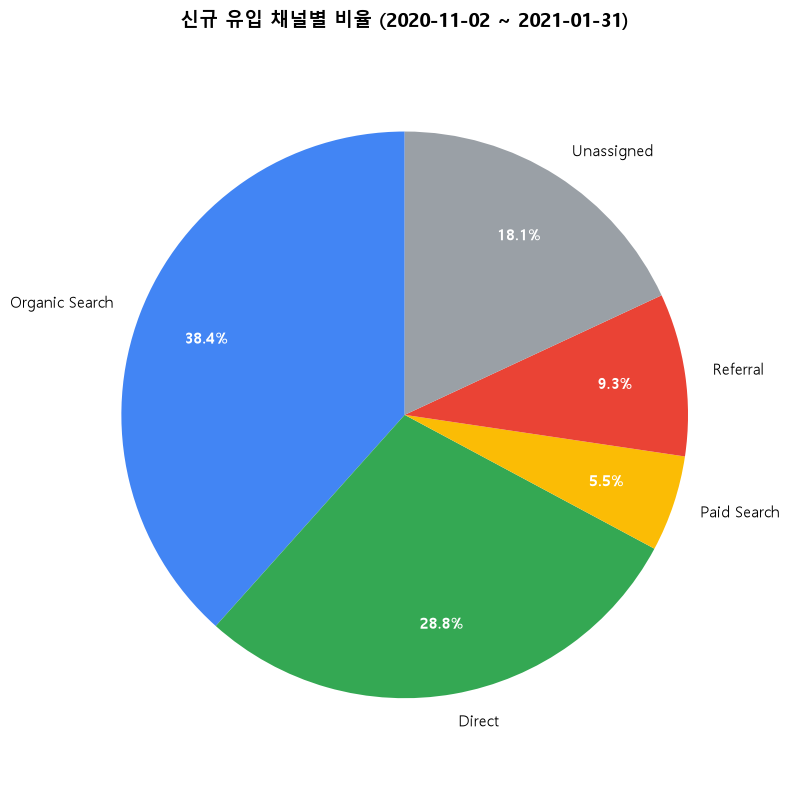

    channel_group  user_cnt   pct
0  Organic Search     98074  38.4
1          Direct     73555  28.8
2     Paid Search     14013   5.5
3        Referral     23711   9.3
4      Unassigned     46163  18.1


In [21]:
# ============================================
# 파이 차트 시각화
# ============================================

# 채널 순서/색상 고정 (일관된 시각화를 위해)
channel_order = ['Organic Search', 'Direct', 'Paid Search', 'Referral', 'Unassigned']
df_channel_sorted = df_channel.set_index('channel_group').reindex(channel_order).reset_index()

colors = ['#4285F4', '#34A853', '#FBBC05', '#EA4335', '#9AA0A6']  # Google 팔레트 + 회색(Unassigned)

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    df_channel_sorted['user_cnt'],
    labels=df_channel_sorted['channel_group'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.75,
    textprops={'fontsize': 11}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('신규 유입 채널별 비율 (2020-11-02 ~ 2021-01-31)', fontsize=14, fontweight='bold', pad=20)
ax.axis('equal')

plt.tight_layout()
plt.savefig('channel_distribution_pie.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_channel_sorted)